# Homework 3: Sequence-to-Sequence Machine Translation

In [138]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [139]:
#imports
%matplotlib inline
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import re
import random
from torch.utils.data import DataLoader, Dataset, RandomSampler, TensorDataset
import nltk
import matplotlib.ticker as ticker # Import ticker for showAttention
import time
import math

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root = '/content/drive/MyDrive/Intro_to_Deep_Learning/HW3/'
#change filepath to run 
filepath = '/content/drive/MyDrive/Intro_to_Deep_Learning/vast_english_french.txt'

In [141]:
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

### Dataset Processing

In [142]:
SOS_token = 0
EOS_token = 1
PAD_token = 2

#Eng and Free will both have a class
class Lang:
  def __init__(self, name):
    self.name = name
    self.word2index = {}
    self.word2count = {}
    self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
    self.n_words = 3

  # When adding a sentence we want to add each word in the sentence to our
  # language dictionary
  def addSentence(self, sentence):
    for word in sentence.split(' '):
      self.addWord(word)
  #If the word isn't in the dictionary, add it with a new index and then add it to the index2word as well
  def addWord(self, word):
    if word not in self.word2index:
      self.word2index[word] = self.n_words
      self.word2count[word] = 1
      self.index2word[self.n_words] = word
      self.n_words += 1
    else:
      self.word2count

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

def readLangs(lang1, lang2, filepath, reverse=False):
    # Read the file and split into lines
    lines = open(filepath , encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [201]:
MAX_LENGTH = 15
def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [ ]:
def prepareData(lang1, lang2, filepath, reverse=False):
    print("Reading lines...")
    input_lang, output_lang, pairs = readLangs(lang1, lang2,filepath, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

## Problem 1: Baseline Encoder-Decoder Architecture

In [328]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.5):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden
class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.0):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.5):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if use_teacher_forcing and target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.dropout(self.embedding(input))
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

### Language helper functions

In [194]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(input_lang, output_lang, pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def pairs_to_dataloader(dataset_pairs, sampler_class, batch_size, input_lang, output_lang, drop_last=False):
    n = len(dataset_pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(dataset_pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    data = TensorDataset(torch.LongTensor(input_ids).to(device),
                                torch.LongTensor(target_ids).to(device))

    sampler = sampler_class(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=batch_size, drop_last=drop_last)
    return dataloader

def get_dataloaders(batch_size, reverse=False):
    filepath = '/content/drive/MyDrive/Intro_to_Deep_Learning/vast_english_french.txt'
    input_lang, output_lang, pairs = prepareData('eng', 'fra', filepath, reverse)

    # Split pairs into train and validation sets with a fixed random_state
    train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    # Pass the locally defined input_lang and output_lang to pairs_to_dataloader
    train_dataloader = pairs_to_dataloader(train_pairs, RandomSampler, batch_size, input_lang, output_lang)
    from torch.utils.data import SequentialSampler
    val_dataloader = pairs_to_dataloader(val_pairs, SequentialSampler, batch_size, input_lang, output_lang)

    return input_lang, output_lang, train_dataloader, val_dataloader, val_pairs

### Training Functions

In [195]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion, teacher_forcing_ratio):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor, teacher_forcing_ratio)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def val_epoch(dataloader, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()
    total_loss = 0
    with torch.no_grad():
        for data in dataloader:
            input_tensor, target_tensor = data

            encoder_outputs, encoder_hidden = encoder(input_tensor)
            # No teacher forcing during validation, so teacher_forcing_ratio is 0 or None
            decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor, teacher_forcing_ratio=0.0)

            loss = criterion(
                decoder_outputs.view(-1, decoder_outputs.size(-1)),
                target_tensor.view(-1)
            )
            total_loss += loss.item()
    return total_loss / len(dataloader)

In [196]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

In [292]:
from torch.optim import lr_scheduler # Added for learning rate scheduler

def train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, initial_tfr=0, min_tfr=0, tfr_rate=0):
    start = time.time()
    train_loss_history = []
    val_loss_history = []
    print_loss_total = 0  # Reset every print_every
    print_val_loss_total = 0 # Added for validation loss

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate, weight_decay=1e-5)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.NLLLoss()

    # Initialize learning rate schedulers
    # ReduceLROnPlateau will reduce LR when validation loss stops improving
    encoder_scheduler = lr_scheduler.ReduceLROnPlateau(encoder_optimizer, 'min', patience=3, factor=0.5)
    decoder_scheduler = lr_scheduler.ReduceLROnPlateau(decoder_optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_epoch = 0
    best_encoder_state = None
    best_decoder_state = None

    for epoch in range(1, n_epochs + 1):
        teacher_forcing_ratio = max(min_tfr, initial_tfr - (epoch - 1) * tfr_rate)

        # Training
        encoder.train() # Set to train mode
        decoder.train() # Set to train mode
        total_train_loss = 0
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, teacher_forcing_ratio)
        print_loss_total += loss
        avg_train_loss = loss
        train_loss_history.append(avg_train_loss)

        # Validation
        total_val_loss = 0
        loss = val_epoch(val_dataloader, encoder, decoder, criterion)
        print_val_loss_total += loss
        avg_val_loss = loss
        val_loss_history.append(avg_val_loss)

        # Step the LR scheduler based on validation loss
        encoder_scheduler.step(avg_val_loss)
        decoder_scheduler.step(avg_val_loss)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            best_encoder_state = encoder.state_dict()
            best_decoder_state = decoder.state_dict()


        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_val_loss_avg = print_val_loss_total / print_every
            print_loss_total = 0
            print_val_loss_total = 0

            print(f'{timeSince(start, epoch / n_epochs)} Epoch: {epoch} Percentage Complete:{epoch / n_epochs * 100:.0f}% Train Loss: {print_loss_avg:.4f} Val Loss: {print_val_loss_avg:.4f} TFR: {teacher_forcing_ratio:.2f}')

    # Load the best model states after training
    if best_encoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
        decoder.load_state_dict(best_decoder_state)
        print(f"\nBest model loaded from epoch {best_epoch} with validation loss: {best_val_loss:.4f}")

    return train_loss_history, val_loss_history, best_epoch

def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        # No teacher forcing during evaluation (teacher_forcing_ratio=0.0)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden, teacher_forcing_ratio=0.0)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('input (EN)', pair[0]) # Corrected label
        print('true output (FR)', pair[1]) # Corrected label
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('pred out (FR)', output_sentence) # Corrected label
        print('')

In [199]:
# Helper function to visualize attention weights
def showAttention(input_sentence_tokens, output_words, attentions, title="Attention Weights", plot_id=None):
    fig = plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    # The input_sentence_tokens should directly correspond to the x-axis of attentions
    # The output_words (without EOS) should directly correspond to the y-axis of attentions
    # Explicitly set tick locations first
    ax.set_xticks(np.arange(len(input_sentence_tokens) + 1))
    ax.set_yticks(np.arange(len(output_words) + 1))
    ax.set_xticklabels([''] + input_sentence_tokens, rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title(title)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping

    # Save the figure with a unique filename
    if plot_id is not None:
        # Sanitize title for filename by replacing spaces with underscores
        filename_title = title.replace(' ', '_').replace(':', '').replace("'", '')
        plt.savefig(f"{root}{filename_title}_{plot_id}.png")
    else:
        # Fallback if no plot_id is provided, though it should be provided now.
        plt.savefig(root+title.replace(' ', '_').replace(':', '').replace("'", '')+'.png')

    plt.show()

def evaluate_dataset(encoder, decoder, pairs, input_lang, output_lang, num_examples=5, attention=False):
    encoder.eval()
    decoder.eval()

    exact_matches = 0
    bleu_scores = []
    inference_time = []
    smoothie = SmoothingFunction().method4

    print(f"Evaluating on {len(pairs)} validation pairs...\n")

    attention_visualizations_count = 0 # Counter for attention plots

    for i, pair in enumerate(pairs):
        input_sentence = pair[0]
        target_sentence = pair[1]
        inference_start_time = time.time()
        # Evaluate function returns output_words (with EOS) and attention weights
        output_words_with_eos, attn_weights = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
        inference_duration = time.time() - inference_start_time
        inference_time.append(inference_duration)

        output_words = output_words_with_eos[:-1]  # Remove the <EOS> token for BLEU and display
        output_sentence = ' '.join([w for w in output_words if w != '<EOS>']) # Sanitize again just in case

        if output_sentence.strip() == target_sentence.strip():
            exact_matches += 1

        reference = [target_sentence.split()]
        candidate = output_sentence.split()
        bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
        bleu_scores.append(bleu)

        if i < num_examples: # Display basic info for num_examples
            print('>', input_sentence)
            print('=', target_sentence)
            print('<', output_sentence)
            print(f'BLEU: {bleu:.4f}\n')

            # Show attention visualization if attention=True and for first 2 examples
            if attention and attention_visualizations_count < 2:
                # Trim attn_weights to actual lengths for better visualization
                # attn_weights shape: (1, predicted_seq_len, input_seq_len_plus_EOS)
                # predicted_seq_len is len(output_words_with_eos)
                # input_seq_len_plus_EOS is len(input_sentence.split(' ')) + 1

                input_tokens_for_plot = input_sentence.split(' ') + ['<EOS>']
                actual_input_tokens_len = len(input_tokens_for_plot)
                actual_output_tokens_len = len(output_words) # Excludes EOS

                # Check if attn_weights is not None and has the expected shape (e.g., from AttnDecoder)
                if attn_weights is not None and attn_weights.dim() == 3:
                  # Slice the attention matrix to match the actual lengths of the input and output tokens
                  attn_matrix_to_plot = attn_weights[0,:actual_output_tokens_len, :actual_input_tokens_len]
                  showAttention(input_tokens_for_plot, output_words, attn_matrix_to_plot,
                                  title=f"Attention for: '{input_sentence}' -> '{output_sentence}'",
                                  plot_id=attention_visualizations_count) # Pass plot_id here
                  attention_visualizations_count += 1 # Increment counter for plots

    accuracy = exact_matches / len(pairs)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    avg_inference_time = sum(inference_time) / len(inference_time)

    print(f"Validation Accuracy (Exact Match): {accuracy:.4f}")
    print(f"Validation Average BLEU Score: {avg_bleu:.4f}")
    print(f"Validation Average Inference Time: {avg_inference_time:.4f}s")


## Problem 1 Execution

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 1s (- 0m 20s) Epoch: 5 Percentage Complete:6% Train Loss: 3.8927 Val Loss: 3.7492 TFR: 0.00
0m 2s (- 0m 19s) Epoch: 10 Percentage Complete:12% Train Loss: 3.1150 Val Loss: 3.4929 TFR: 0.00
0m 4s (- 0m 17s) Epoch: 15 Percentage Complete:19% Train Loss: 2.8930 Val Loss: 3.4126 TFR: 0.00
0m 5s (- 0m 16s) Epoch: 20 Percentage Complete:25% Train Loss: 2.7163 Val Loss: 3.3794 TFR: 0.00
0m 6s (- 0m 14s) Epoch: 25 Percentage Complete:31% Train Loss: 2.5655 Val Loss: 3.3656 TFR: 0.00
0m 8s (- 0m 13s) Epoch: 30 Percentage Complete:38% Train Loss: 2.4674 Val Loss: 3.3724 TFR: 0.00
0m 9s (- 0m 12s) Epoch: 35 Percentage Complete:44% Train Loss: 2.4265 Val Loss: 3.3739 TFR: 0.00
0m 10s (- 0m 10s) Epoch: 40 Percentage Complete:50% Train Loss: 2.4062 Val Loss: 3.3738 TFR: 0.00
0m 12s (- 0m 9s) Epoch: 45 Percentage Complete:56% Train Loss: 2.4031 Val Loss: 3.3762 TFR: 0.00
0m 13s

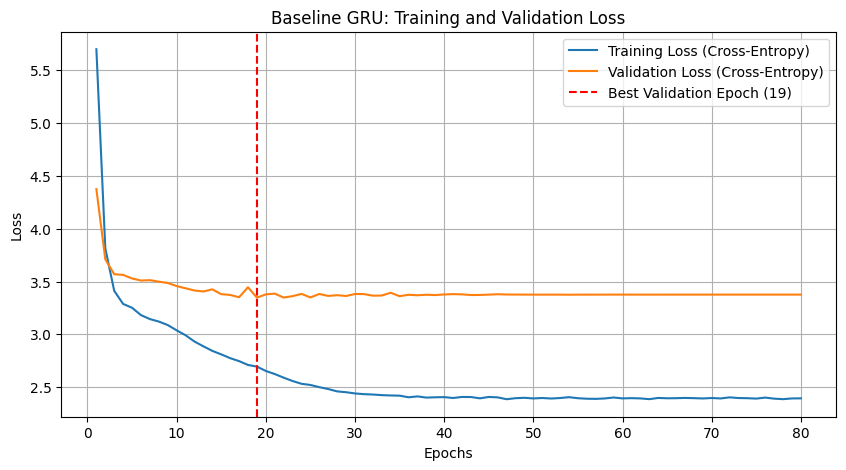

In [303]:
hidden_size = 128
batch_size = 32
n_epochs =80
input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = Decoder(hidden_size, output_lang.n_words,).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Baseline GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'baseline_loss_curve.png') # Saves the image for your PDF report
plt.show()

In [220]:
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

input (EN) we are going to buy groceries
true output (FR) nous allons faire des courses
pred out (FR) le le un <EOS>

input (EN) he cleans his desk every evening
true output (FR) il nettoie son bureau chaque soir
pred out (FR) il aime un <EOS>

input (EN) we swim during summer
true output (FR) nous nageons pendant l t
pred out (FR) le a un <EOS>

input (EN) the regional train arrives at exactly six o clock
true output (FR) le train r gional arrive exactement six heures
pred out (FR) nous avons un une de de de de de <EOS>

input (EN) we work in the office
true output (FR) nous travaillons au bureau
pred out (FR) le le <EOS>

input (EN) they visit the eiffel tower
true output (FR) ils visitent la tour eiffel
pred out (FR) nous avons un une de de de <EOS>

input (EN) the keys are on the desk
true output (FR) les cl s sont sur le bureau
pred out (FR) le a un <EOS>

input (EN) she walks along the beach
true output (FR) elle se prom ne le long de la plage
pred out (FR) nous avons un une de d

In [304]:
print("\n--- Final Evaluation ---")
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5)


--- Final Evaluation ---
Evaluating on 111 validation pairs...

> they speak french at home
= ils parlent fran ais la maison
< le parlent
BLEU: 0.0091

> we need to buy some eggs
= nous devons acheter des ufs
< elle a un
BLEU: 0.0000

> my phone is broken
= mon t l phone est cass
< le SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> he completed the online assessment very early
= il a termin l valuation en ligne tr s t t
< le avons est la le le
BLEU: 0.0000

> i truly enjoy walking in the dense forest
= j aime vraiment marcher dans la for t dense
< le avons de la le
BLEU: 0.0205

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0150
Validation Average Inference Time: 0.0049s


With teacher forcing

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 1s (- 0m 20s) Epoch: 5 Percentage Complete:6% Train Loss: 3.7138 Val Loss: 3.8798 TFR: 0.96
0m 2s (- 0m 18s) Epoch: 10 Percentage Complete:12% Train Loss: 2.8661 Val Loss: 3.9466 TFR: 0.91
0m 4s (- 0m 17s) Epoch: 15 Percentage Complete:19% Train Loss: 2.8703 Val Loss: 3.7017 TFR: 0.86
0m 5s (- 0m 16s) Epoch: 20 Percentage Complete:25% Train Loss: 2.7777 Val Loss: 3.6039 TFR: 0.81
0m 6s (- 0m 14s) Epoch: 25 Percentage Complete:31% Train Loss: 2.8035 Val Loss: 3.5420 TFR: 0.76
0m 8s (- 0m 13s) Epoch: 30 Percentage Complete:38% Train Loss: 2.7363 Val Loss: 3.5235 TFR: 0.71
0m 9s (- 0m 12s) Epoch: 35 Percentage Complete:44% Train Loss: 2.7705 Val Loss: 3.4818 TFR: 0.66
0m 10s (- 0m 10s) Epoch: 40 Percentage Complete:50% Train Loss: 2.7597 Val Loss: 3.4582 TFR: 0.61
0m 12s (- 0m 9s) Epoch: 45 Percentage Complete:56% Train Loss: 2.7376 Val Loss: 3.4218 TFR: 0.56
0m 13s

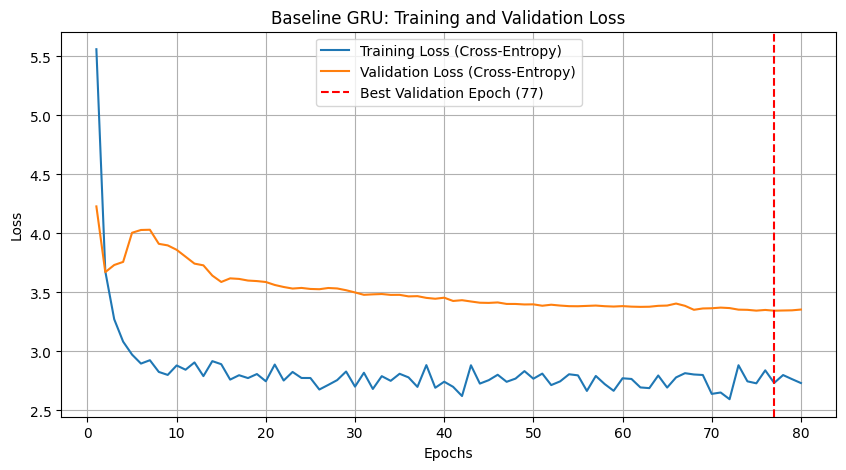

In [305]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = Decoder(hidden_size, output_lang.n_words).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Baseline GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'baselineTFR_loss_curve.png') # Saves the image for your PDF report
plt.show()

In [306]:
print("\n--- Final Evaluation ---")
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5)


--- Final Evaluation ---
Evaluating on 111 validation pairs...

> she paints her nails red
= elle se peint les ongles en rouge
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> the birds chirp in the morning
= les oiseaux gazouillent le matin
< elle
BLEU: 0.0000

> i see a rainbow in the sky
= je vois un arc en ciel dans le ciel
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> he reads the newspaper
= il lit le journal
< il a une de
BLEU: 0.0610

> the black tea is too sweet to drink comfortably
= le th noir est trop sucr pour tre bu confortablement
< il a un de
BLEU: 0.0000

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0163
Validation Average Inference Time: 0.0049s


With Decoder Dropout

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 1s (- 0m 21s) Epoch: 5 Percentage Complete:6% Train Loss: 3.8536 Val Loss: 3.8030 TFR: 0.96
0m 2s (- 0m 20s) Epoch: 10 Percentage Complete:12% Train Loss: 2.9199 Val Loss: 3.7487 TFR: 0.91
0m 4s (- 0m 18s) Epoch: 15 Percentage Complete:19% Train Loss: 2.8730 Val Loss: 3.6515 TFR: 0.86
0m 5s (- 0m 17s) Epoch: 20 Percentage Complete:25% Train Loss: 2.8633 Val Loss: 3.6142 TFR: 0.81
0m 7s (- 0m 15s) Epoch: 25 Percentage Complete:31% Train Loss: 2.9345 Val Loss: 3.5553 TFR: 0.76
0m 8s (- 0m 14s) Epoch: 30 Percentage Complete:38% Train Loss: 2.9369 Val Loss: 3.4885 TFR: 0.71
0m 10s (- 0m 12s) Epoch: 35 Percentage Complete:44% Train Loss: 2.9111 Val Loss: 3.4695 TFR: 0.66
0m 11s (- 0m 11s) Epoch: 40 Percentage Complete:50% Train Loss: 2.9136 Val Loss: 3.4551 TFR: 0.61
0m 12s (- 0m 10s) Epoch: 45 Percentage Complete:56% Train Loss: 2.9467 Val Loss: 3.4173 TFR: 0.56
0m 1

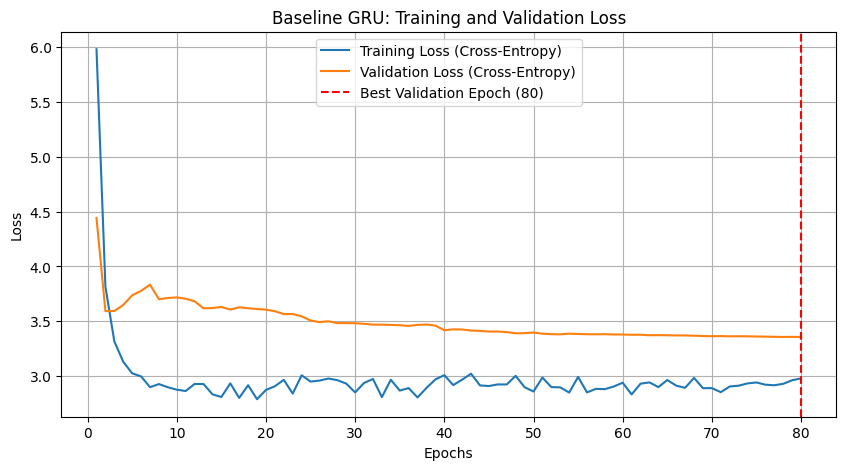

In [332]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = Decoder(hidden_size, output_lang.n_words, dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Baseline GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'baselineTFR2_loss_curve.png') # Saves the image for your PDF report
plt.show()

In [333]:
print("\n--- Final Evaluation ---")
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5)


--- Final Evaluation ---
Evaluating on 111 validation pairs...

> they built a campfire last night
= ils ont fait un feu de camp hier soir
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> she translates technical documents
= elle traduit des documents techniques
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> they live near a beautiful lake
= ils vivent pr s d un beau lac
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> she bought an expensive leather bag yesterday
= elle a achet un sac en cuir cher hier
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> she wears a beautiful silver bracelet on her wrist
= elle porte un beau bracelet en argent au poignet
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0108
Validation Average Inference Time: 0.0052s


## Problem 2: Sequence-to-Sequence with Attention

In [156]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)

    def forward(self, query, keys):
        new_keys = self.Wa(keys)
        scores = torch.bmm(query, new_keys.transpose(1, 2))

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.0, attn='B'):
        super(AttnDecoder, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attn = attn.upper()
        # Bahdanau Attention larger GRU
        if self.attn=='B':
            self.attention = BahdanauAttention(hidden_size)
            self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        elif self.attn=='L':
          #Luong Attention, standard GRU, larger linear bc of when attention is computed
            self.attention = LuongAttention(hidden_size)
            self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
            self.wc = nn.Linear(2*hidden_size, hidden_size)
        else:
            raise ValueError("Invalid attention type. Choose 'B' for Bahdanau or 'L' for Luong.")

        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.5):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if use_teacher_forcing and target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        if self.attn == 'B':
          query = hidden.permute(1, 0, 2)
          context, attn_weights = self.attention(query, encoder_outputs)
          input_gru = torch.cat((embedded, context), dim=2)

          output, hidden = self.gru(input_gru, hidden)
          output = self.out(output)
        elif self.attn == 'L':
            output, hidden = self.gru(embedded, hidden)
            context, attn_weights = self.attention(output, encoder_outputs)
            concat_output = torch.cat((output, context), dim=2)
            combined = torch.tanh(self.wc(concat_output))
            output = self.out(combined)

        return output, hidden, attn_weights

## Problem 2 Execution

### Bahdanau Attention

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 2s (- 0m 37s) Epoch: 5 Percentage Complete:6% Train Loss: 3.6970 Val Loss: 3.4419 TFR: 0.00
0m 5s (- 0m 35s) Epoch: 10 Percentage Complete:12% Train Loss: 2.6878 Val Loss: 2.9821 TFR: 0.00
0m 7s (- 0m 33s) Epoch: 15 Percentage Complete:19% Train Loss: 2.2859 Val Loss: 2.8013 TFR: 0.00
0m 10s (- 0m 30s) Epoch: 20 Percentage Complete:25% Train Loss: 1.9308 Val Loss: 2.6957 TFR: 0.00
0m 12s (- 0m 27s) Epoch: 25 Percentage Complete:31% Train Loss: 1.6290 Val Loss: 2.6292 TFR: 0.00
0m 15s (- 0m 25s) Epoch: 30 Percentage Complete:38% Train Loss: 1.3840 Val Loss: 2.5955 TFR: 0.00
0m 17s (- 0m 22s) Epoch: 35 Percentage Complete:44% Train Loss: 1.1770 Val Loss: 2.5829 TFR: 0.00
0m 20s (- 0m 20s) Epoch: 40 Percentage Complete:50% Train Loss: 0.9914 Val Loss: 2.5638 TFR: 0.00
0m 22s (- 0m 17s) Epoch: 45 Percentage Complete:56% Train Loss: 0.8227 Val Loss: 2.5387 TFR: 0.00
0

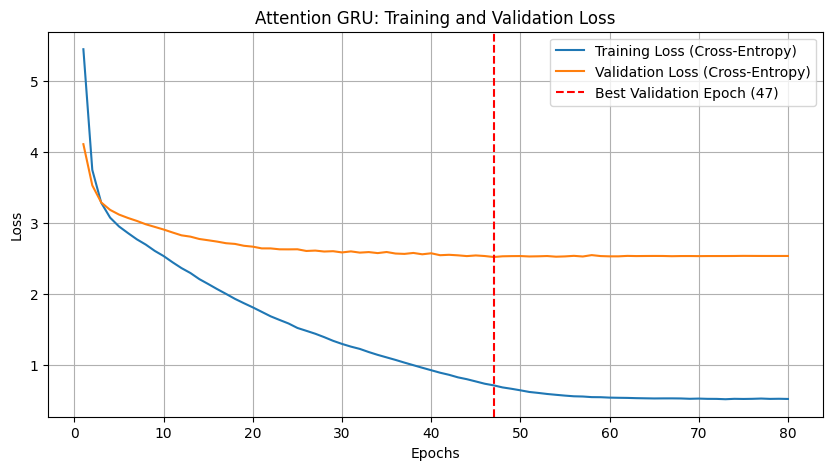

In [320]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'AttentionB_loss_curve.png') # Saves the image for your PDF report
plt.show()

In [228]:
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

input (EN) the championship football match was incredibly intense
true output (FR) le match de football du championnat tait incroyablement intense
pred out (FR) le train a d une nouvelle paire de la plage de la plage de la

input (EN) we are planning a trip to rome
true output (FR) nous planifions un voyage rome
pred out (FR) le train a d un roman de chaussures de chaussures de la plage de la

input (EN) the coffee is very strong
true output (FR) le caf est tr s fort
pred out (FR) le chat grimpe sur le parc s midi <EOS>

input (EN) the guide is easy to read
true output (FR) le guide est facile lire
pred out (FR) le chat grimpe sur le parc s midi <EOS>

input (EN) they feed the birds in the park
true output (FR) ils nourrissent les oiseaux dans le parc
pred out (FR) le chat grimpe sur le parc s midi <EOS>

input (EN) we are ready to start the game
true output (FR) nous sommes pr ts commencer le jeu
pred out (FR) le chat grimpe sur le parc s midi de la plage de la plage de

input (EN) i 

Evaluating on 111 validation pairs...

> the summer is very hot here
= l t est tr s chaud ici
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000



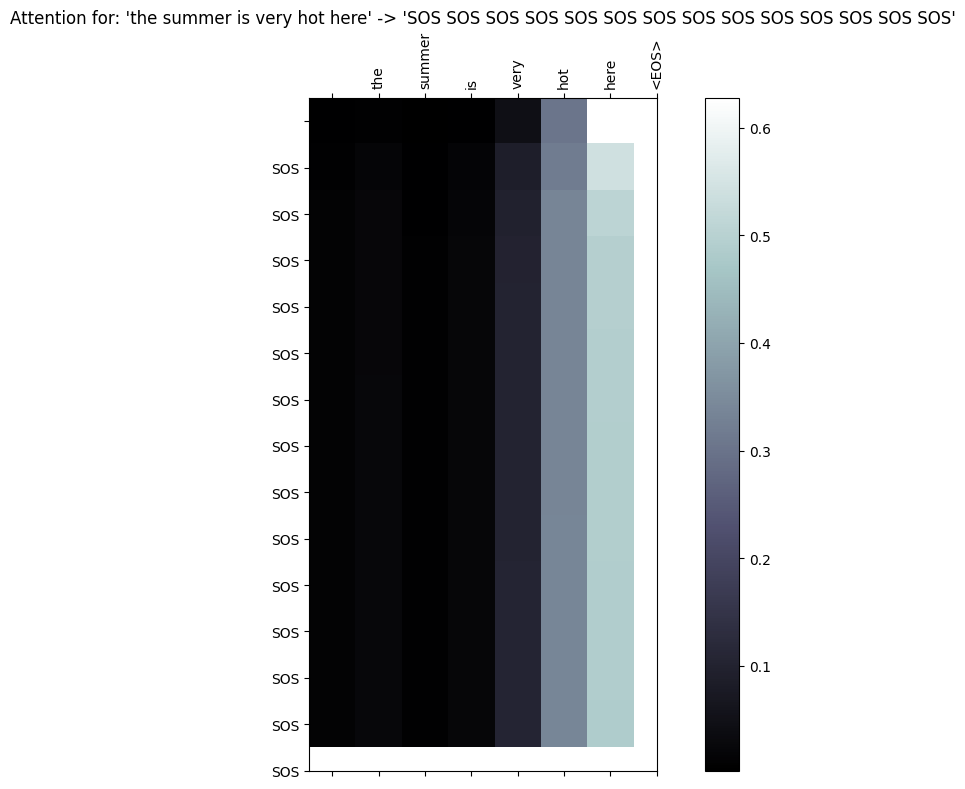

> the coffee is very strong
= le caf est tr s fort
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000



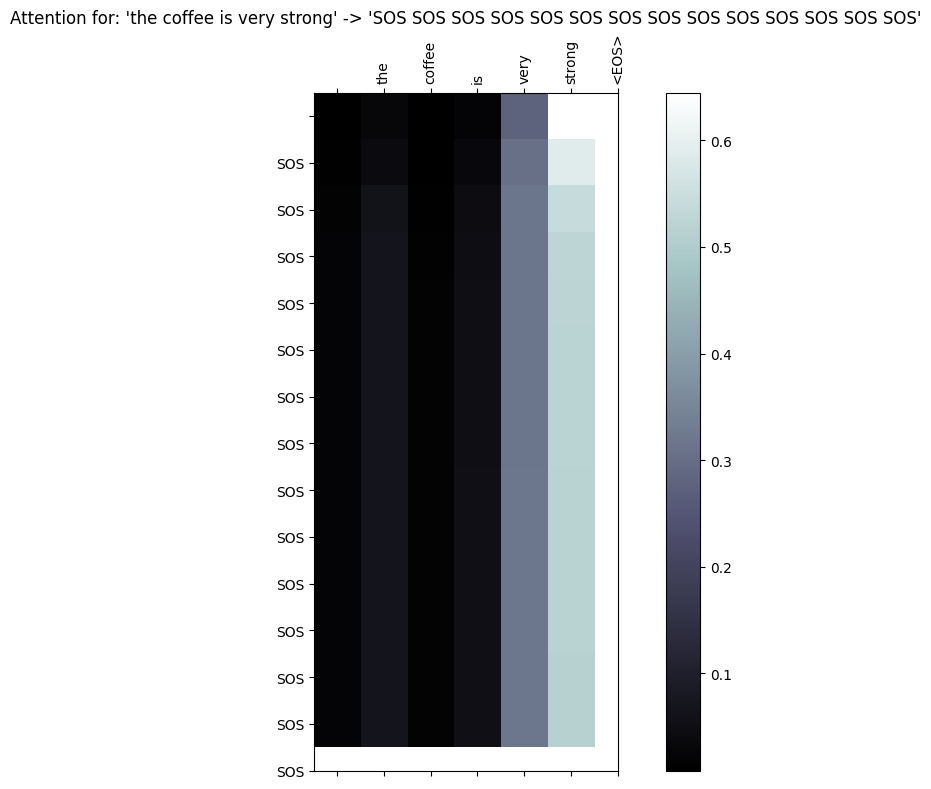

> she makes delicious cakes
= elle fait de d licieux g teaux
< elle adore porter des vestes modernes
BLEU: 0.0318

> we walk through the historic streets of paris
= nous marchons dans les rues historiques de paris
< nous avons travers le parc national pendant nos vacances d or dans le parc
BLEU: 0.0209

> the book is on the table
= le livre est sur la table
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0309
Validation Average Inference Time: 0.0092s


In [321]:
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5,attention=True)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 2s (- 0m 38s) Epoch: 5 Percentage Complete:6% Train Loss: 3.6158 Val Loss: 3.3779 TFR: 0.96
0m 5s (- 0m 35s) Epoch: 10 Percentage Complete:12% Train Loss: 2.7055 Val Loss: 2.9926 TFR: 0.91
0m 7s (- 0m 33s) Epoch: 15 Percentage Complete:19% Train Loss: 2.3280 Val Loss: 2.8160 TFR: 0.86
0m 10s (- 0m 30s) Epoch: 20 Percentage Complete:25% Train Loss: 1.9627 Val Loss: 2.6975 TFR: 0.81
0m 12s (- 0m 27s) Epoch: 25 Percentage Complete:31% Train Loss: 1.6494 Val Loss: 2.6468 TFR: 0.76
0m 15s (- 0m 25s) Epoch: 30 Percentage Complete:38% Train Loss: 1.3836 Val Loss: 2.6177 TFR: 0.71
0m 17s (- 0m 22s) Epoch: 35 Percentage Complete:44% Train Loss: 1.1479 Val Loss: 2.5881 TFR: 0.66
0m 20s (- 0m 20s) Epoch: 40 Percentage Complete:50% Train Loss: 0.9443 Val Loss: 2.5720 TFR: 0.61
0m 22s (- 0m 17s) Epoch: 45 Percentage Complete:56% Train Loss: 0.7815 Val Loss: 2.5650 TFR: 0.56
0

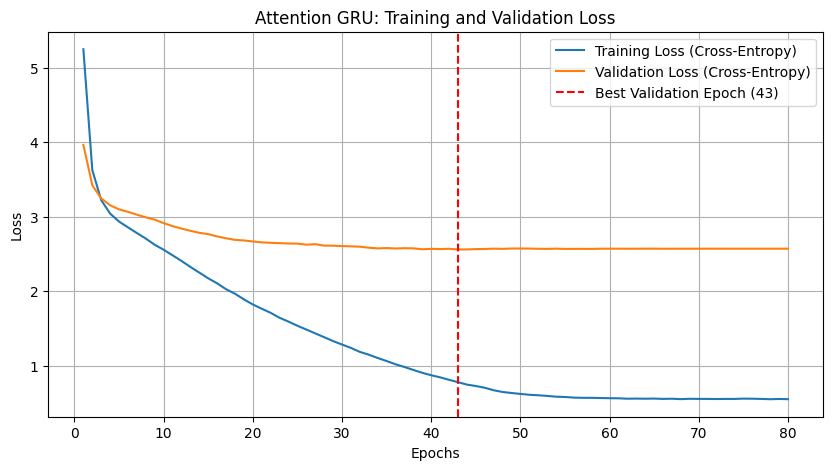

In [322]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'AttentionB_loss_curve.png') # Saves the image for your PDF report
plt.show()

Evaluating on 111 validation pairs...

> we watched the spectacular sunrise over the ocean
= nous avons regard le lever de soleil spectaculaire sur l oc an
< nous avons travers le parc national pendant le coucher de la fontaine
BLEU: 0.0568



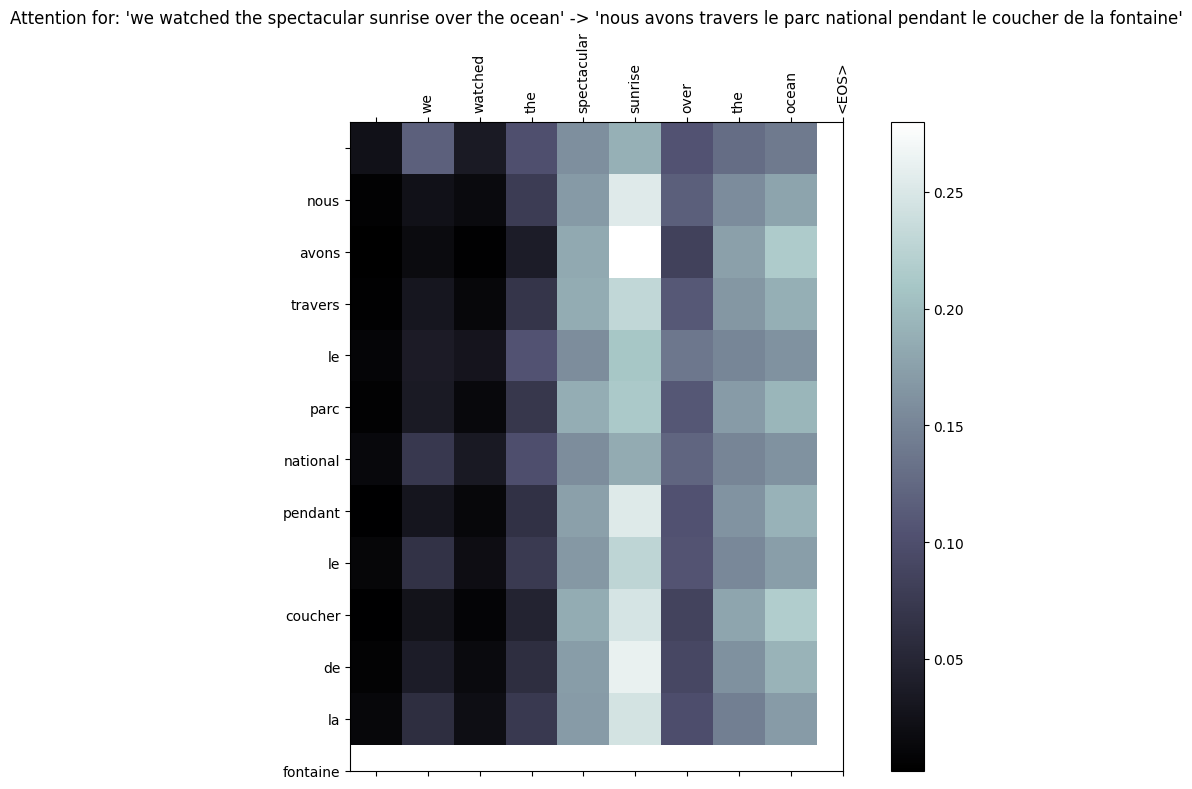

> they practice swimming techniques every single afternoon
= ils s entra nent aux techniques de natation chaque apr s midi
< ils s entra nent la course de fond tous les matins avant le soir
BLEU: 0.1880



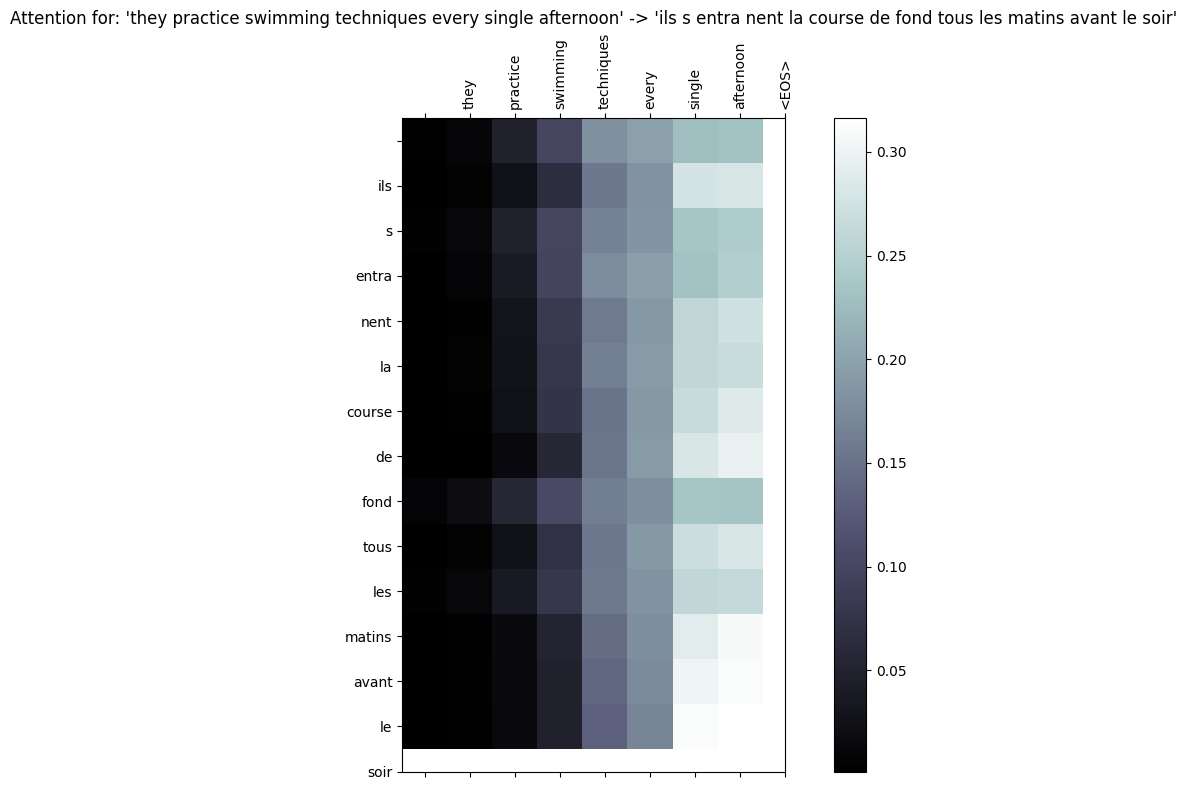

> we went for a walk in the woods
= nous sommes all s nous promener dans les bois
< nous avons travers le parc national pendant nos dans le parc national
BLEU: 0.0238

> we celebrated their golden wedding anniversary yesterday
= nous avons c l br leur anniversaire de mariage d or hier
< nous allons au mus e en bois demain matin
BLEU: 0.0184

> i am currently reading a fascinating historical biography
= je lis actuellement une biographie historique fascinante
< j ai re u une nouvelle paire de chaussures
BLEU: 0.0257

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0415
Validation Average Inference Time: 0.0093s


In [323]:
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5,attention=True)

### Luong Attention

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 2s (- 0m 35s) Epoch: 5 Percentage Complete:6% Train Loss: 3.7174 Val Loss: 3.4060 TFR: 0.00
0m 4s (- 0m 32s) Epoch: 10 Percentage Complete:12% Train Loss: 2.8622 Val Loss: 2.9551 TFR: 0.00
0m 7s (- 0m 30s) Epoch: 15 Percentage Complete:19% Train Loss: 2.5668 Val Loss: 2.8307 TFR: 0.00
0m 9s (- 0m 28s) Epoch: 20 Percentage Complete:25% Train Loss: 2.2889 Val Loss: 2.7384 TFR: 0.00
0m 11s (- 0m 25s) Epoch: 25 Percentage Complete:31% Train Loss: 2.0031 Val Loss: 2.6410 TFR: 0.00
0m 14s (- 0m 23s) Epoch: 30 Percentage Complete:38% Train Loss: 1.7034 Val Loss: 2.5517 TFR: 0.00
0m 16s (- 0m 21s) Epoch: 35 Percentage Complete:44% Train Loss: 1.4167 Val Loss: 2.4782 TFR: 0.00
0m 18s (- 0m 18s) Epoch: 40 Percentage Complete:50% Train Loss: 1.1736 Val Loss: 2.4521 TFR: 0.00
0m 21s (- 0m 16s) Epoch: 45 Percentage Complete:56% Train Loss: 0.9625 Val Loss: 2.4413 TFR: 0.00
0m

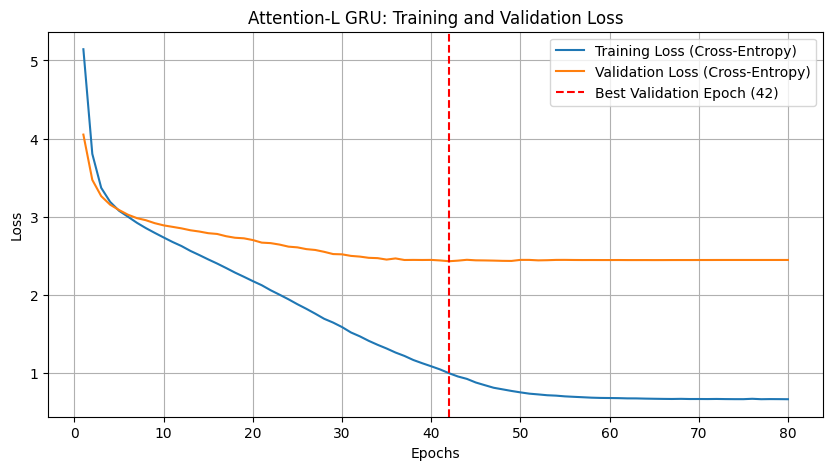

In [324]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, attn='L', dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention-L GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'AttentionL_loss_curve.png') # Saves the image for your PDF report
plt.show()


Evaluating on 111 validation pairs...

> the coffee is very strong
= le caf est tr s fort
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000



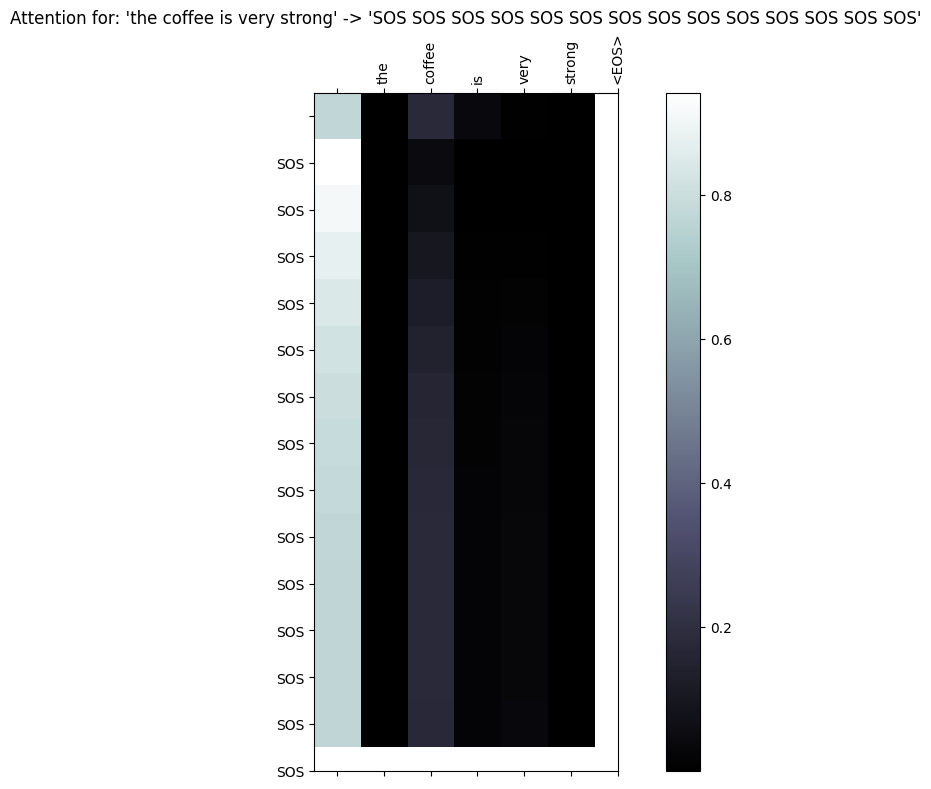

> the doctor advised me to rest
= le m decin m a conseill de me reposer
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000



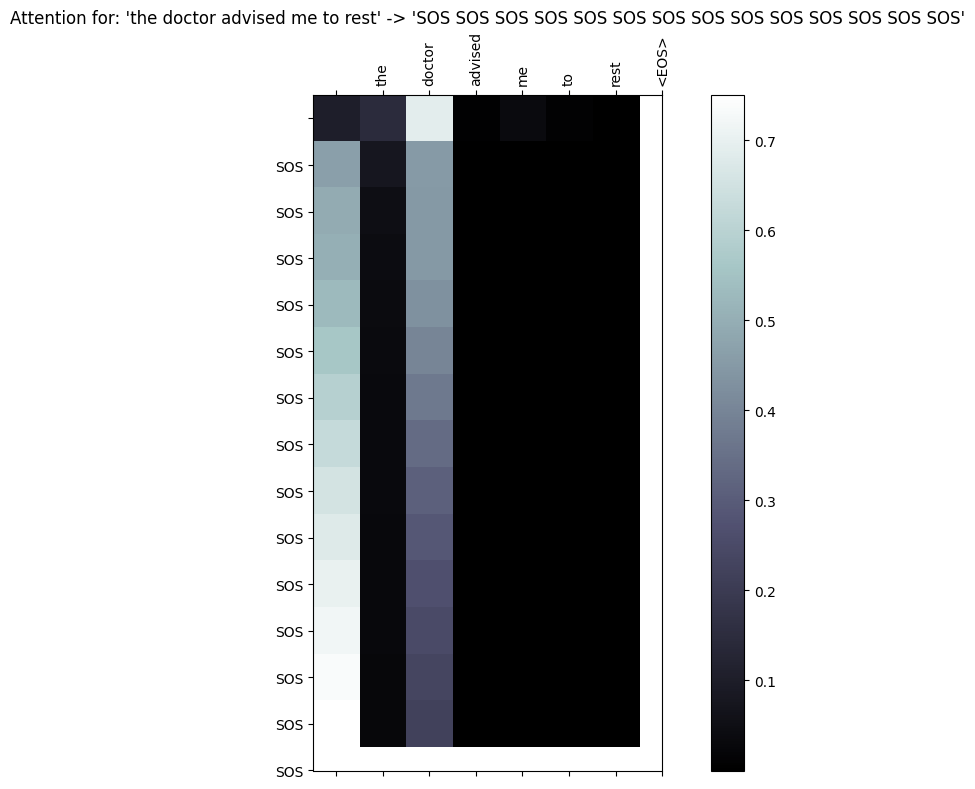

> he works hard every day
= il travaille dur tous les jours
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> the computer screen is covered in fingerprints
= l cran de l ordinateur est couvert d empreintes digitales
< SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0000

> i urgently need a new pair of running shoes
= j ai un besoin urgent d une nouvelle paire de chaussures de course
< j SOS je veux un brouillard microscope classique dimanche dimanche dimanche dimanche dimanche dimanche
BLEU: 0.0209

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0110
Validation Average Inference Time: 0.0080s


In [325]:
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5, attention=True)

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
eng 1003
fra 1127
0m 2s (- 0m 35s) Epoch: 5 Percentage Complete:6% Train Loss: 3.6680 Val Loss: 3.6047 TFR: 0.96
0m 4s (- 0m 32s) Epoch: 10 Percentage Complete:12% Train Loss: 2.7186 Val Loss: 3.1486 TFR: 0.91
0m 6s (- 0m 30s) Epoch: 15 Percentage Complete:19% Train Loss: 2.3204 Val Loss: 2.9462 TFR: 0.86
0m 9s (- 0m 27s) Epoch: 20 Percentage Complete:25% Train Loss: 1.9598 Val Loss: 2.8202 TFR: 0.81
0m 11s (- 0m 25s) Epoch: 25 Percentage Complete:31% Train Loss: 1.6478 Val Loss: 2.7592 TFR: 0.76
0m 14s (- 0m 23s) Epoch: 30 Percentage Complete:38% Train Loss: 1.3748 Val Loss: 2.7332 TFR: 0.71
0m 16s (- 0m 20s) Epoch: 35 Percentage Complete:44% Train Loss: 1.1485 Val Loss: 2.7389 TFR: 0.66
0m 18s (- 0m 18s) Epoch: 40 Percentage Complete:50% Train Loss: 0.9841 Val Loss: 2.7417 TFR: 0.61
0m 20s (- 0m 16s) Epoch: 45 Percentage Complete:56% Train Loss: 0.9219 Val Loss: 2.7449 TFR: 0.56
0m

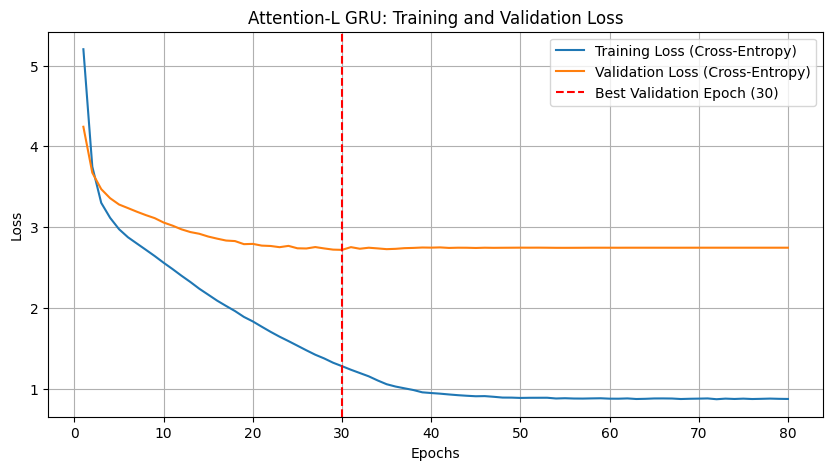

In [326]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, attn='L', dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention-L GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'AttentionL1_loss_curve.png') # Saves the image for your PDF report
plt.show()

Evaluating on 111 validation pairs...

> the pizza tastes good
= la pizza a bon go t
< le ciel est d licieuse
BLEU: 0.0000



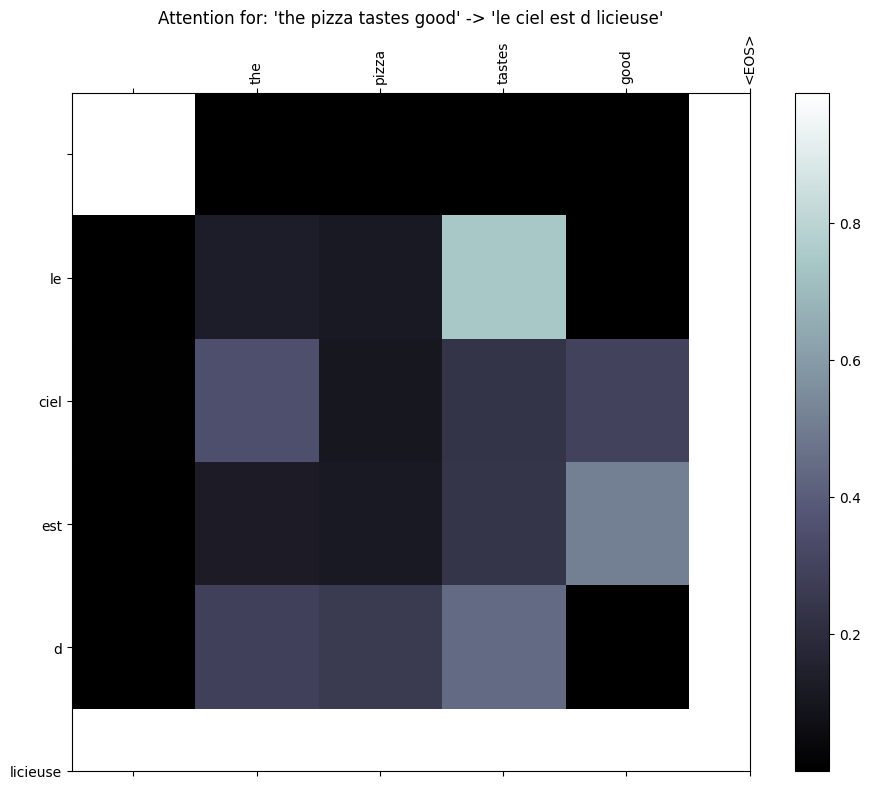

> we cook dinner together
= nous cuisinons le d ner ensemble
< nous avons visit l br leur mariage de dipl la pyramide t l phone
BLEU: 0.0176



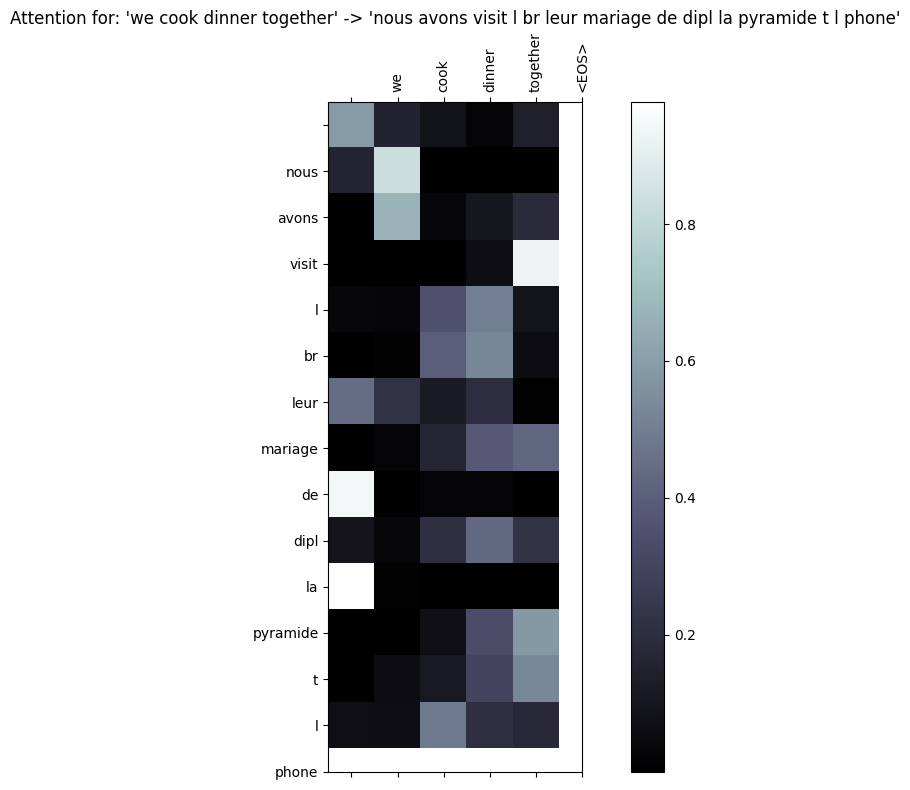

> where is the station ?
= o est la gare ?
< le petit match de tennis
BLEU: 0.0000

> the museum is an educational place
= le mus e est un lieu ducatif
< le pain est aujourd hui
BLEU: 0.0364

> they live in a large metropolitan city
= ils vivent dans une grande ville m tropolitaine
< ils ont un beau beau en b ton en ton SOS SOS SOS SOS
BLEU: 0.0176

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0517
Validation Average Inference Time: 0.0080s


In [327]:
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5, attention=True)

## Problem 3:  Reversing the Language Direction

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
fra 1127
eng 1003
0m 1s (- 0m 21s) Epoch: 5 Percentage Complete:6% Train Loss: 3.3484 Val Loss: 3.2134 TFR: 0.96
0m 2s (- 0m 20s) Epoch: 10 Percentage Complete:12% Train Loss: 2.3503 Val Loss: 2.9745 TFR: 0.91
0m 4s (- 0m 18s) Epoch: 15 Percentage Complete:19% Train Loss: 2.2069 Val Loss: 2.8354 TFR: 0.86
0m 5s (- 0m 17s) Epoch: 20 Percentage Complete:25% Train Loss: 2.1437 Val Loss: 2.7851 TFR: 0.81
0m 7s (- 0m 15s) Epoch: 25 Percentage Complete:31% Train Loss: 2.0675 Val Loss: 2.7388 TFR: 0.76
0m 8s (- 0m 14s) Epoch: 30 Percentage Complete:38% Train Loss: 1.9615 Val Loss: 2.7452 TFR: 0.71
0m 10s (- 0m 13s) Epoch: 35 Percentage Complete:44% Train Loss: 1.9508 Val Loss: 2.7299 TFR: 0.66
0m 11s (- 0m 11s) Epoch: 40 Percentage Complete:50% Train Loss: 1.9404 Val Loss: 2.7309 TFR: 0.61
0m 13s (- 0m 10s) Epoch: 45 Percentage Complete:56% Train Loss: 1.9396 Val Loss: 2.7335 TFR: 0.56
0m 1

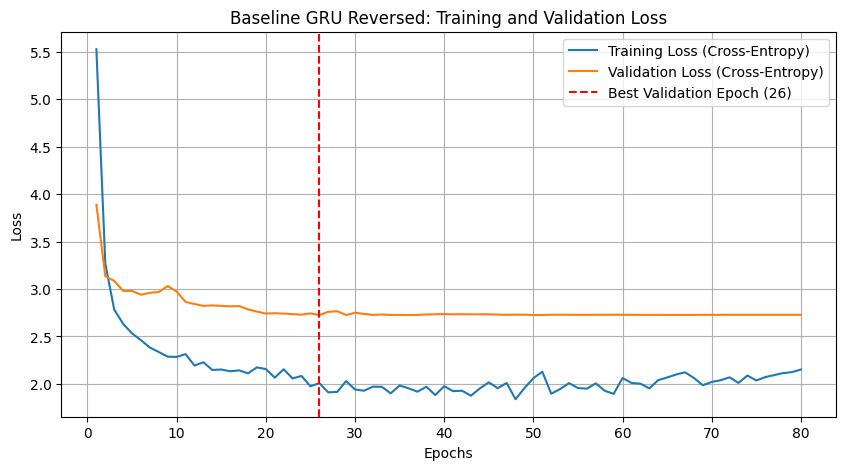

Evaluating on 111 validation pairs...

> elle boit toujours du lait chaud avant de se coucher
= she always drinks warm milk before going to bed
< he decided to a to the
BLEU: 0.0228

> j attends le week end avec impatience
= i look forward to the weekend
< he decided to a trip to
BLEU: 0.0376

> les toiles scintillent la nuit
= the stars twinkle at night
< he writes a to the
BLEU: 0.0456

> l cran de l ordinateur est couvert d empreintes digitales
= the computer screen is covered in fingerprints
< he decided to a to the
BLEU: 0.0318

> le fleuriste du coin vend des roses fra ches
= the flower shop on the corner sells fresh roses
< he decided to a to the
BLEU: 0.0228

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0326
Validation Average Inference Time: 0.0052s


In [334]:
hidden_size = 128
batch_size = 32
n_epochs = 80

input_lang, output_lang, train_dataloader, val_dataloader, val_pairs = get_dataloaders(batch_size, True)

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = Decoder(hidden_size, output_lang.n_words, dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Baseline GRU Reversed: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'baselineflipped_loss_curve.png') # Saves the image for your PDF report
plt.show()
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5)

Attention

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
fra 1127
eng 1003
0m 2s (- 0m 37s) Epoch: 5 Percentage Complete:6% Train Loss: 3.1521 Val Loss: 2.8886 TFR: 0.96
0m 5s (- 0m 36s) Epoch: 10 Percentage Complete:12% Train Loss: 2.1842 Val Loss: 2.4328 TFR: 0.91
0m 7s (- 0m 33s) Epoch: 15 Percentage Complete:19% Train Loss: 1.8509 Val Loss: 2.2854 TFR: 0.86
0m 10s (- 0m 30s) Epoch: 20 Percentage Complete:25% Train Loss: 1.5724 Val Loss: 2.1966 TFR: 0.81
0m 12s (- 0m 28s) Epoch: 25 Percentage Complete:31% Train Loss: 1.3323 Val Loss: 2.1524 TFR: 0.76
0m 15s (- 0m 25s) Epoch: 30 Percentage Complete:38% Train Loss: 1.1178 Val Loss: 2.1173 TFR: 0.71
0m 17s (- 0m 22s) Epoch: 35 Percentage Complete:44% Train Loss: 0.9323 Val Loss: 2.0921 TFR: 0.66
0m 20s (- 0m 20s) Epoch: 40 Percentage Complete:50% Train Loss: 0.7645 Val Loss: 2.0726 TFR: 0.61
0m 22s (- 0m 17s) Epoch: 45 Percentage Complete:56% Train Loss: 0.6300 Val Loss: 2.0616 TFR: 0.56
0

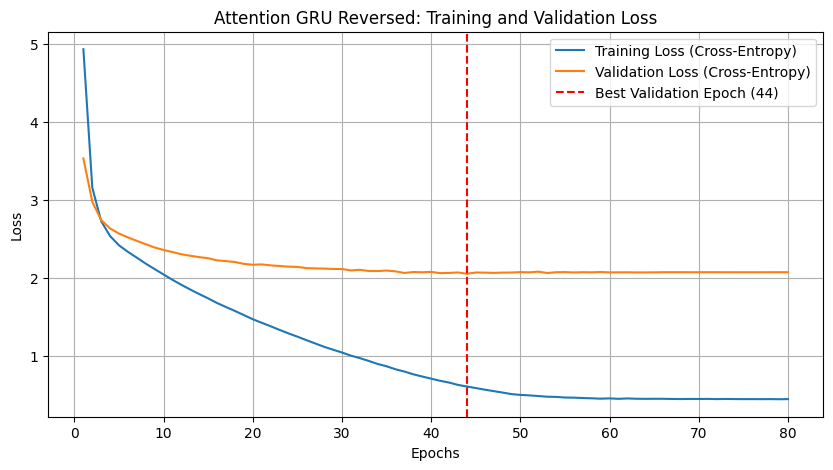

Evaluating on 111 validation pairs...

> le mus e est un lieu ducatif
= the museum is an educational place
< the library is a quiet place
BLEU: 0.0495



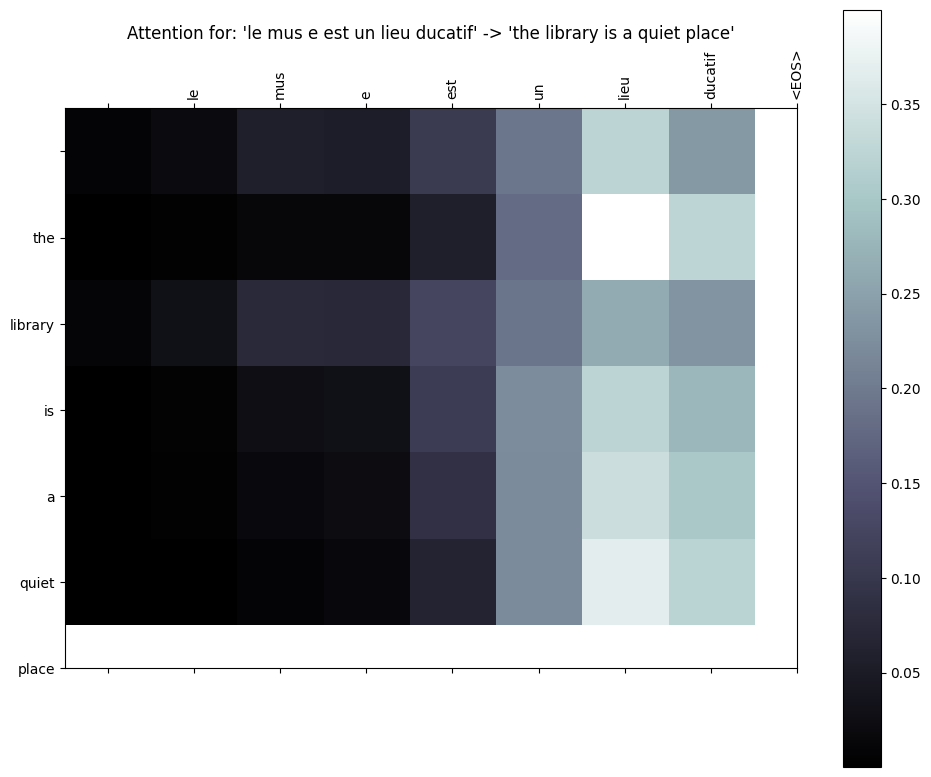

> le train part midi
= the train leaves at noon
< the emergency phone call within seconds
BLEU: 0.0376



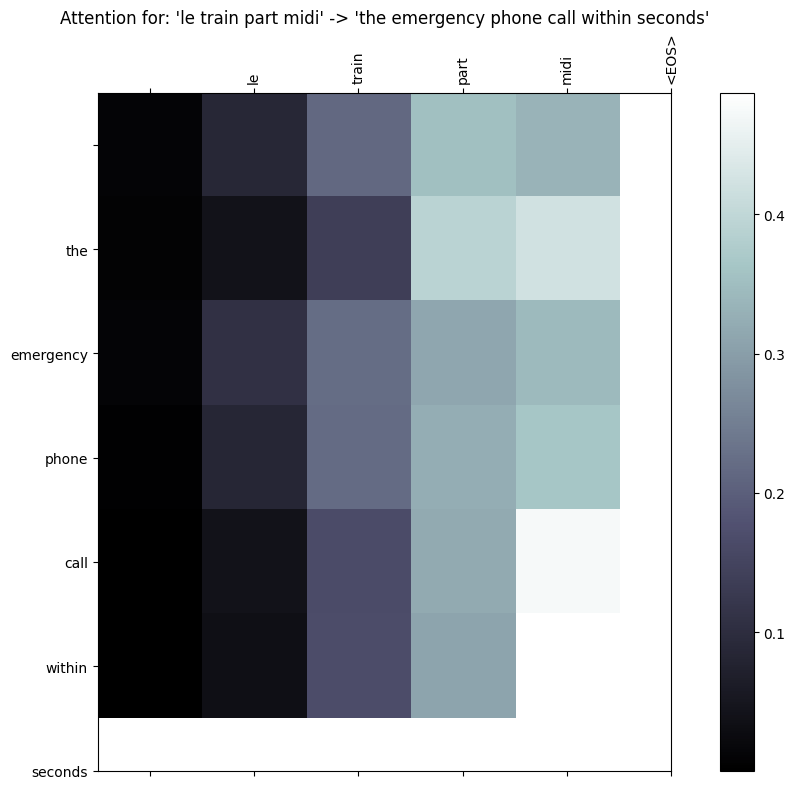

> je vois un navire au loin
= i see a ship in the distance
< i want a large cruise ship in the distance
BLEU: 0.3303

> il conduit une moto rouge
= he drives a red motorcycle
< he drives a green truck
BLEU: 0.2995

> je r parerai le robinet qui fuit demain matin
= i will fix the leaky faucet tomorrow morning
< i want to dye the international flight
BLEU: 0.0334

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0692
Validation Average Inference Time: 0.0091s


In [ ]:
hidden_size = 128
batch_size = 32
n_epochs = 80

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, attn='B', dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention GRU Reversed: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'FlippedAttnB_loss_curve.png') # Saves the image for your PDF report
plt.show()
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5, attention=True)

English to French Luong

Reading lines...
Read 555 sentence pairs
Trimmed to 551 sentence pairs
Counting words...
Counted words:
fra 1127
eng 1003
0m 2s (- 0m 34s) Epoch: 5 Percentage Complete:6% Train Loss: 3.2889 Val Loss: 2.8671 TFR: 0.96
0m 4s (- 0m 32s) Epoch: 10 Percentage Complete:12% Train Loss: 2.3512 Val Loss: 2.4422 TFR: 0.91
0m 6s (- 0m 29s) Epoch: 15 Percentage Complete:19% Train Loss: 2.0555 Val Loss: 2.3259 TFR: 0.86
0m 9s (- 0m 27s) Epoch: 20 Percentage Complete:25% Train Loss: 1.7745 Val Loss: 2.2159 TFR: 0.81
0m 11s (- 0m 25s) Epoch: 25 Percentage Complete:31% Train Loss: 1.5206 Val Loss: 2.1400 TFR: 0.76
0m 13s (- 0m 23s) Epoch: 30 Percentage Complete:38% Train Loss: 1.3071 Val Loss: 2.1200 TFR: 0.71
0m 16s (- 0m 20s) Epoch: 35 Percentage Complete:44% Train Loss: 1.1170 Val Loss: 2.1062 TFR: 0.66
0m 18s (- 0m 18s) Epoch: 40 Percentage Complete:50% Train Loss: 0.9407 Val Loss: 2.1079 TFR: 0.61
0m 20s (- 0m 16s) Epoch: 45 Percentage Complete:56% Train Loss: 0.8340 Val Loss: 2.1028 TFR: 0.56
0m

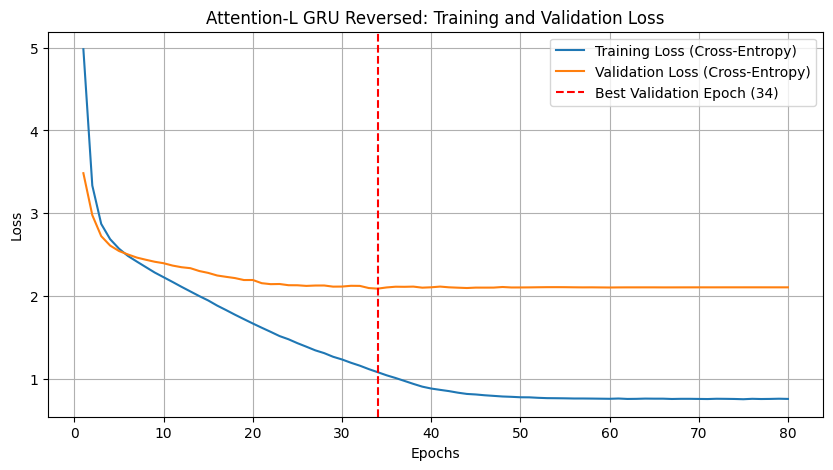

Evaluating on 111 validation pairs...

> il parle couramment quatre langues
= he speaks four languages fluently
< he works his entire languages fluently fluently
BLEU: 0.0907



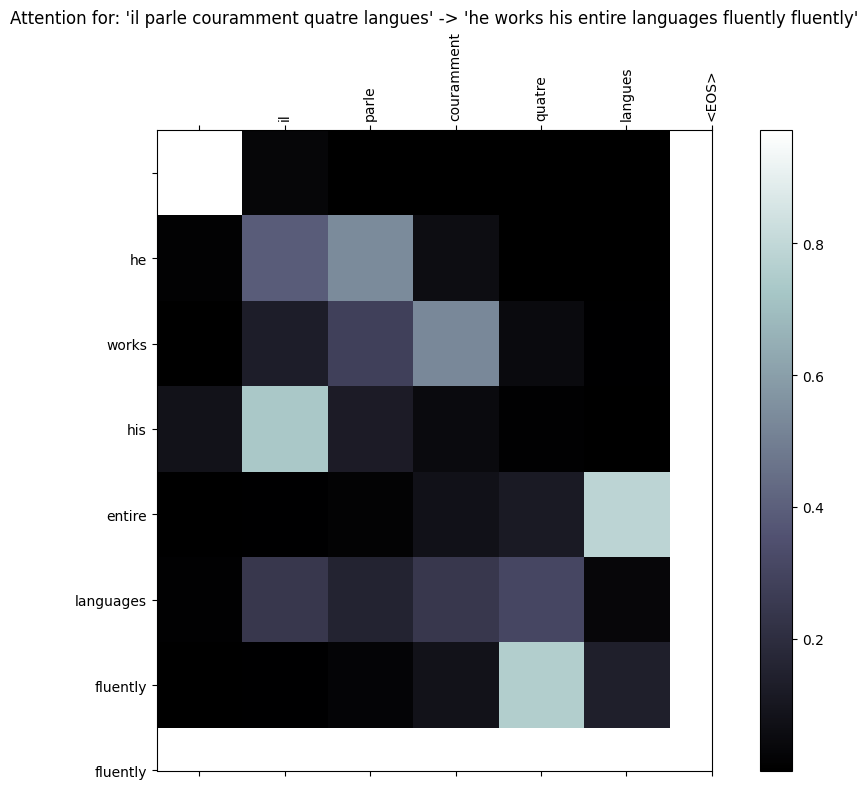

> elle parle anglais avec assurance
= she speaks english with confidence
< she works part time at her free time
BLEU: 0.0286



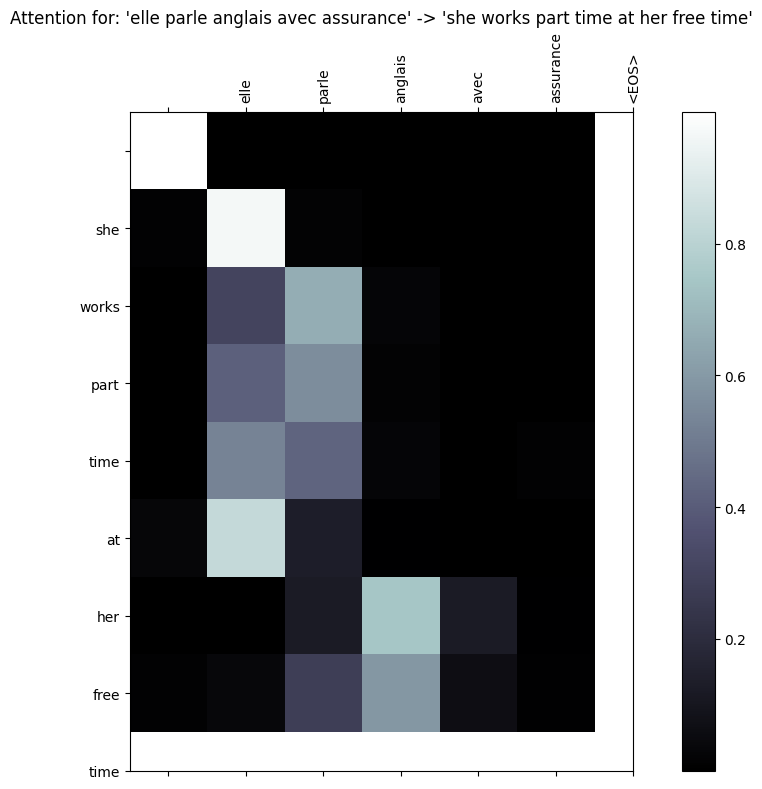

> j attends avec impatience d assister la conf rence technologique
= i look forward to attending the tech conference
< i need my keys somewhere in SOS SOS SOS SOS SOS SOS SOS SOS
BLEU: 0.0176

> je ne trouve mon passeport nulle part dans la chambre
= i cannot find my passport anywhere in the room
< i will walking through the national park
BLEU: 0.0289

> elle tudie les math matiques l universit
= she studies mathematics at university
< she works part time at the national park
BLEU: 0.0340

Validation Accuracy (Exact Match): 0.0000
Validation Average BLEU Score: 0.0465
Validation Average Inference Time: 0.0082s


In [ ]:
hidden_size = 128
batch_size = 32
n_epochs = 80

encoder = Encoder(input_lang.n_words, hidden_size, dropout_p=0.3).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words, attn='L', dropout_p=0.2).to(device)

train_history, val_history, best_epoch = train(train_dataloader, val_dataloader, encoder, decoder, n_epochs, print_every=5, initial_tfr=1, min_tfr=0.0, tfr_rate=0.01)
# Plotting the Evaluation Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_history, label='Training Loss (Cross-Entropy)')
plt.plot(range(1, n_epochs + 1), val_history, label='Validation Loss (Cross-Entropy)')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Validation Epoch ({best_epoch})')
plt.title('Attention-L GRU Reversed: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(root+'FlippedAttnL_loss_curve.png') # Saves the image for your PDF report
plt.show()
evaluate_dataset(encoder, decoder, val_pairs, input_lang, output_lang, num_examples=5, attention=True)